In [63]:
import pandas as pd
import mlflow
import joblib
df = pd.read_csv("../data/raw/data.csv")

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


Section 1 Load Data

Section 2 Overview

In [2]:
df.shape

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult        

Section 3 Missing Values

In [3]:
df.isnull().sum()

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

Section 4 Summary Statistics

In [4]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


Section 5 Numerical Distributions

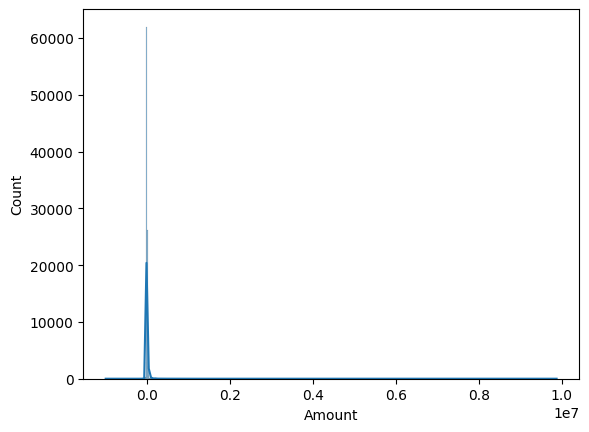

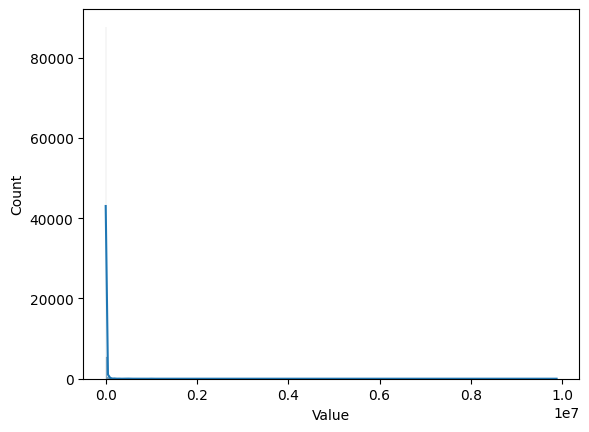

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ["Amount","Value"]

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.show()

Section 6 Categorical Distributions

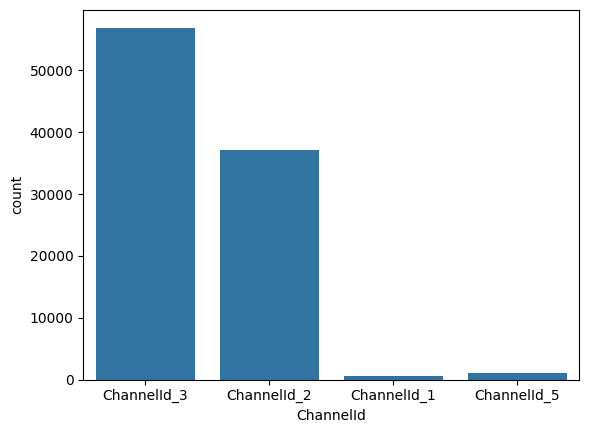

In [6]:
sns.countplot(x="ChannelId", data=df)
plt.show()

Section 7 Correlation

<Axes: >

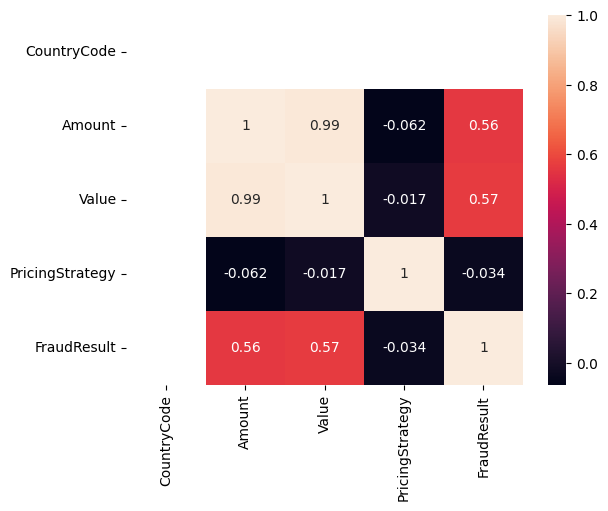

In [7]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

Section 8 Outliers

<Axes: ylabel='Amount'>

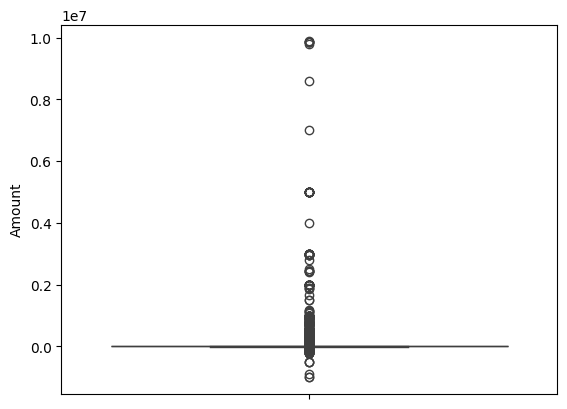

In [8]:
sns.boxplot(df["Amount"])

Section 9 Final Insights
1. Amount is highly skewed.
2. Most transactions occur through a small number of channels.
3. Fraud is highly imbalanced.
4. Significant outliers exist.
5. Transaction value strongly correlates with amount.

Feature Engineering
Create data_processing.py
Step 1 Aggregate Features

In [9]:
customer_features = df.groupby("CustomerId").agg({
    "Amount":["sum","mean","std"],
    "TransactionId":"count"
})

Rename

In [10]:
customer_features.columns = [
    "total_amount",
    "avg_amount",
    "std_amount",
    "transaction_count"
]

In [11]:
customer_features.head()

,total_amount,avg_amount,std_amount,transaction_count
CustomerId,,,,
CustomerId_1,-10000.0,-10000.000000,NaN,1
CustomerId_10,-10000.0,-10000.000000,NaN,1
CustomerId_1001,20000.0,4000.000000,6558.963333,5
CustomerId_1002,4225.0,384.090909,560.498966,11
CustomerId_1003,20000.0,3333.333333,6030.478146,6


Step 2 Extract Time Features

In [12]:
df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)

df["hour"] = df["TransactionStartTime"].dt.hour
df["day"] = df["TransactionStartTime"].dt.day
df["month"] = df["TransactionStartTime"].dt.month
df["year"] = df["TransactionStartTime"].dt.year

Step 3 Handle Missing Values

In [13]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

Step 4 Encoding

In [14]:
from sklearn.preprocessing import OneHotEncoder

Step 5 Scaling

In [15]:
from sklearn.preprocessing import StandardScaler

Step 6 Build Pipeline

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [17]:
import pandas as pd

df = pd.read_csv("../data/raw/data.csv")

In [18]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [19]:
df.shape

(95662, 16)

In [20]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(numerical_cols)
print(categorical_cols)

['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult']
['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'TransactionStartTime']


In [21]:
preprocessor = ColumnTransformer(
[
("num",
 Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
 ]),
 numerical_cols),

("cat",
 Pipeline([
   ("imputer",
    SimpleImputer(strategy="most_frequent")),
   ("encoder",
    OneHotEncoder(handle_unknown="ignore"))
 ]),
 categorical_cols)
]
)

Step 7 WoE

TASK 4 — Create Proxy Target
Step 1 RFM Calculation

In [22]:
df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"])

In [23]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0


In [24]:
df["TransactionStartTime"].dtype

datetime64[ns, UTC]

In [25]:
snapshot_date = df["TransactionStartTime"].max() + pd.Timedelta(days=1)

In [26]:
df[["TransactionStartTime"]].head()

,TransactionStartTime
0,2018-11-15 02:18:49+00:00
1,2018-11-15 02:19:08+00:00
2,2018-11-15 02:44:21+00:00
3,2018-11-15 03:32:55+00:00
4,2018-11-15 03:34:21+00:00


In [27]:
df["TransactionStartTime"].dtype

datetime64[ns, UTC]

In [28]:
rfm = df.groupby("CustomerId").agg(
{
"TransactionStartTime":
 lambda x:(snapshot_date-x.max()).days,

"TransactionId":"count",

"Amount":"sum"
}
)

In [29]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

Step 2 Scale

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)


Step 3 KMeans

In [31]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm["cluster"] = kmeans.fit_predict(rfm_scaled)

In [32]:
rfm.head()

,Recency,Frequency,Monetary,cluster
CustomerId,,,,
CustomerId_1,84,1,-10000.0,0
CustomerId_10,84,1,-10000.0,0
CustomerId_1001,90,5,20000.0,0
CustomerId_1002,26,11,4225.0,1
CustomerId_1003,12,6,20000.0,1


Step 4 Find High Risk Cluster

In [33]:
rfm.groupby("cluster").mean()


,Recency,Frequency,Monetary
cluster,,,
0,61.877279,7.720196,8.172068e+04
1,12.726566,34.800000,2.725741e+05
2,29.000000,4091.000000,-1.049000e+08


In [34]:
high_risk_cluster = 0

Create Label

In [35]:
rfm["is_high_risk"] = (
rfm["cluster"] == high_risk_cluster
).astype(int)


In [36]:
rfm.head()

,Recency,Frequency,Monetary,cluster,is_high_risk
CustomerId,,,,,
CustomerId_1,84,1,-10000.0,0,1
CustomerId_10,84,1,-10000.0,0,1
CustomerId_1001,90,5,20000.0,0,1
CustomerId_1002,26,11,4225.0,1,0
CustomerId_1003,12,6,20000.0,1,0


Merge Back

In [37]:
df = df.merge(
    rfm[["is_high_risk"]],
    left_on="CustomerId",
    right_index=True,
    how="left"
)

In [38]:
print(df.columns)

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult',
       'is_high_risk'],
      dtype='object')


Save

In [39]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/processed.csv", index=False)


TASK 5 — Model Training + MLflow
Step 3: Load the processed dataset

In [40]:
import os

print(os.path.exists("../data/processed/processed.csv"))

True


In [41]:
df = pd.read_csv("../data/processed/processed.csv")

Step 4: Separate features and target

In [42]:
print(df.columns)

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult',
       'is_high_risk'],
      dtype='object')


In [43]:
print(rfm.columns)

Index(['Recency', 'Frequency', 'Monetary', 'cluster', 'is_high_risk'], dtype='object')


Step 4: Separate features and target

In [44]:
X = df.drop(columns=["is_high_risk"])
y = df["is_high_risk"]

Step 5: Train/Test Split

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Step 6: Train Logistic Regression

In [47]:
from sklearn.linear_model import LogisticRegression

In [48]:
X_train = X_train.drop(columns=['TransactionId'])
X_test = X_test.drop(columns=['TransactionId'])

In [49]:
X_train = X_train.select_dtypes(exclude=['object'])
X_test = X_test.select_dtypes(exclude=['object'])

In [50]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# align columns (important!)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [51]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

Step 7: Train Random Forest

In [52]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

Step 8: Hyperparameter Tuning

In [54]:
from sklearn.model_selection import GridSearchCV

In [55]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

Step 9: Evaluate

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [57]:
pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, pred))

Accuracy: 0.8862175299221241
Precision: 0.7906976744186046
Recall: 0.015440508628519528
F1: 0.030289532293986638
ROC AUC: 0.5074544696588937


Step 10: MLflow

Wrap training inside:

In [58]:
with mlflow.start_run():
    mlflow.log_param("model", "RandomForest")

Then log parameters:

In [59]:
mlflow.log_param("model", "RandomForest")

mlflow.log_param("n_estimators", grid.best_params_["n_estimators"])

mlflow.log_param("max_depth", grid.best_params_["max_depth"])

10

Log metrics:

In [60]:
mlflow.log_metric(
    "accuracy",
    accuracy_score(y_test, pred)
)

mlflow.log_metric(
    "precision",
    precision_score(y_test, pred)
)

mlflow.log_metric(
    "recall",
    recall_score(y_test, pred)
)

mlflow.log_metric(
    "f1",
    f1_score(y_test, pred)
)

mlflow.log_metric(
    "roc_auc",
    roc_auc_score(y_test, pred)
)

Log model:

In [61]:
mlflow.sklearn.log_model(
    best_model,
    "credit_risk_model"
)

2026/06/07 01:29:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 01:29:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Save locally:

In [64]:
joblib.dump(best_model, "model.pkl")

['model.pkl']

Step 11: Register Model

In [67]:
mlflow.end_run()

In [68]:
import mlflow

with mlflow.start_run() as run:
    print("Run ID:", run.info.run_id)

Run ID: 11afabcfe6cd4616a41ff00e8ff639db


login

In [72]:
import mlflow
import mlflow.sklearn

with mlflow.start_run() as run:
    mlflow.sklearn.log_model(
        rf,
        "credit_risk_model",
        serialization_format="cloudpickle"
    )

2026/06/07 01:59:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 01:59:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [77]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# make sure no old broken run is active
mlflow.end_run()

rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

with mlflow.start_run() as run:
    mlflow.log_param("model", "RandomForest")
    mlflow.log_metric("accuracy", accuracy_score(y_test, pred))

    mlflow.sklearn.log_model(rf, "model")

    print("RUN CREATED:", run.info.run_id)

2026/06/07 02:16:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 02:16:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RUN CREATED: bb7d30edb58c4a818b8a50eaac43534b


In [78]:
mlflow.register_model(
    "runs:/bb7d30edb58c4a818b8a50eaac43534b/model",
    "CreditRiskModel"
)

Registered model 'CreditRiskModel' already exists. Creating a new version of this model...
2026/06/07 02:25:38 WARNING mlflow.tracking._model_registry.fluent: Run with id bb7d30edb58c4a818b8a50eaac43534b has no artifacts at artifact path 'model', registering model based on models:/m-3475c7d0cc3442048c011c59414ed807 instead
Created version '1' of model 'CreditRiskModel'.


<ModelVersion: aliases=[], creation_timestamp=1780788338780, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1780788338780, metrics=None, model_id=None, name='CreditRiskModel', params=None, run_id='bb7d30edb58c4a818b8a50eaac43534b', run_link=None, source='models:/m-3475c7d0cc3442048c011c59414ed807', status='READY', status_message=None, tags={}, user_id=None, version=1, workspace='default'>

Step 12: Unit Tests